# NYC TLC Green Taxi Trip Record Analysis

## Background

The New York City Taxi and Limousine Commission (TLC) collects trip-level data from all
licensed taxi and for-hire vehicle companies operating in New York City. This dataset covers
**Green Taxi** (boro taxi) trips for **January 2023**.

Green taxis were introduced in 2013 to serve outer-borough and upper-Manhattan neighbourhoods
that yellow cabs historically underserved. Understanding their operational patterns is critical
for fleet management, fare policy, driver income optimisation, and urban transport planning.


## Problem Statement

TLC regulators and fleet operators want to understand **how, when, and where Green Taxi
service is being used** in order to:

1. **Optimise driver scheduling** by identifying peak-demand windows.
2. **Evaluate revenue streams** — fare, tip, and surcharge — across trip characteristics.
3. **Assess vendor performance** for the two licensed technology providers.
4. **Detect data-quality issues** that erode analytical reliability and revenue accuracy.
5. **Inform geographic deployment** by pinpointing the highest-demand taxi zones.

As data analysts, we aim to answer:

> **What are the key temporal, financial, and operational patterns of Green Taxi trips in
> January 2023, and what actionable recommendations can be drawn from these patterns?**


# Data

The dataset `nyc_tlc_trip_record.csv` contains **68,211 rows** and **20 columns** covering
NYC Green Taxi trips.

| Column | Description |
|--------|-------------|
| `VendorID` | Technology provider (1 = CMT, 2 = VeriFone) |
| `lpep_pickup_datetime` | Date & time the meter was engaged |
| `lpep_dropoff_datetime` | Date & time the meter was disengaged |
| `store_and_fwd_flag` | Trip record held in vehicle memory before sending (Y/N) |
| `RatecodeID` | Final rate code (1=Standard, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=Negotiated, 99=Unknown) |
| `PULocationID` | TLC Taxi Zone ID where meter was engaged |
| `DOLocationID` | TLC Taxi Zone ID where meter was disengaged |
| `passenger_count` | Number of passengers (driver-entered) |
| `trip_distance` | Elapsed trip distance in miles |
| `fare_amount` | Time-and-distance fare computed by the meter |
| `extra` | Miscellaneous extras and surcharges |
| `mta_tax` | MTA tax (automatically triggered) |
| `tip_amount` | Tip — auto-populated for credit-card tips only |
| `tolls_amount` | Total amount of all tolls paid |
| `ehail_fee` | e-hail fee (deprecated — not in use) |
| `improvement_surcharge` | Improvement surcharge assessed on hailed trips |
| `total_amount` | Total amount charged to passengers |
| `payment_type` | How passenger paid (1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown) |
| `trip_type` | How trip was obtained (1=Street-hail, 2=Dispatch) |
| `congestion_surcharge` | NYC Congestion Surcharge (applies to CBD trips) |

Below are the first and last five rows of the raw dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal

import warnings
warnings.filterwarnings('ignore')

# Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11


In [2]:
# Load raw dataset — low_memory=False prevents mixed-type inference warnings
df_raw = pd.read_csv('nyc_tlc_trip_record.csv', low_memory=False)

print(f'Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
display(df_raw.head())
display(df_raw.tail())


Dataset shape: 68,211 rows × 20 columns


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2023-01-01 00:26:10,2023-01-01 00:37:11,N,1.0000,166,143,1.0000,2.5800,14.9000,1.0000,0.5000,4.0300,0.0000,NaN,1.0000,24.1800,1.0000,1.0000,2.7500
1,2,2023-01-01 00:51:03,2023-01-01 00:57:49,N,1.0000,24,43,1.0000,1.8100,10.7000,1.0000,0.5000,2.6400,0.0000,NaN,1.0000,15.8400,1.0000,1.0000,0.0000
2,2,2023-01-01 00:35:12,2023-01-01 00:41:32,N,1.0000,223,179,1.0000,0.0000,7.2000,1.0000,0.5000,1.9400,0.0000,NaN,1.0000,11.6400,1.0000,1.0000,0.0000
3,1,2023-01-01 00:13:14,2023-01-01 00:19:03,N,1.0000,41,238,1.0000,1.3000,6.5000,0.5000,1.5000,1.7000,0.0000,NaN,1.0000,10.2000,1.0000,1.0000,0.0000
4,1,2023-01-01 00:33:04,2023-01-01 00:39:02,N,1.0000,41,74,1.0000,1.1000,6.0000,0.5000,1.5000,0.0000,0.0000,NaN,1.0000,8.0000,1.0000,1.0000,0.0000


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
68206,2,2023-01-31 22:29:00,2023-01-31 22:42:00,NaN,NaN,49,62,NaN,4070.8200,15.7000,0.0000,0.0000,0.0000,0.0000,NaN,1.0000,16.7000,NaN,NaN,NaN
68207,2,2023-01-31 22:40:00,2023-01-31 22:48:00,NaN,NaN,10,205,NaN,2.1400,4.4100,0.0000,0.0000,0.0000,0.0000,NaN,1.0000,5.4100,NaN,NaN,NaN
68208,2,2023-01-31 23:46:00,2023-02-01 00:02:00,NaN,NaN,66,37,NaN,3.4400,16.5300,0.0000,0.0000,3.5100,0.0000,NaN,1.0000,21.0400,NaN,NaN,NaN
68209,2,2023-01-31 23:01:00,2023-01-31 23:19:00,NaN,NaN,225,189,NaN,3.0300,14.9800,0.0000,0.0000,3.2000,0.0000,NaN,1.0000,19.1800,NaN,NaN,NaN
68210,2,2023-01-31 23:51:00,2023-02-01 00:07:00,NaN,NaN,256,140,NaN,5.8200,23.6500,0.0000,0.0000,2.0000,0.0000,NaN,1.0000,29.4000,NaN,NaN,NaN


## Data Understanding & Cleaning

Before any analysis we must understand the dataset's structure, summary statistics,
missing-value patterns, and anomalies. Every cleaning decision is justified by domain
knowledge (TLC data dictionary) and/or statistical evidence.


In [3]:
# Structural overview: data types and non-null counts
print(f'Shape: {df_raw.shape}')
df_raw.info()


Shape: (68211, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68211 entries, 0 to 68210
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               68211 non-null  int64  
 1   lpep_pickup_datetime   68211 non-null  object 
 2   lpep_dropoff_datetime  68211 non-null  object 
 3   store_and_fwd_flag     63887 non-null  object 
 4   RatecodeID             63887 non-null  float64
 5   PULocationID           68211 non-null  int64  
 6   DOLocationID           68211 non-null  int64  
 7   passenger_count        63887 non-null  float64
 8   trip_distance          68211 non-null  float64
 9   fare_amount            68211 non-null  float64
 10  extra                  68211 non-null  float64
 11  mta_tax                68211 non-null  float64
 12  tip_amount             68211 non-null  float64
 13  tolls_amount           68211 non-null  float64
 14  ehail_fee              0 non-null  

In [4]:
# Numeric summary statistics — reveals plausible ranges and potential outliers
display(df_raw.describe())

# Categorical summary statistics
display(df_raw.describe(include='object'))


,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,68211.0000,63887.0000,68211.0000,68211.0000,63887.0000,68211.0000,68211.0000,68211.0000,68211.0000,68211.0000,68211.0000,0.0000,68211.0000,68211.0000,63887.0000,63877.0000,63887.0000
mean,1.8630,1.1172,98.5497,138.4299,1.3159,8.1149,16.6035,0.8254,0.5883,2.1390,0.1696,NaN,0.9516,21.7894,1.3736,1.0219,0.7267
std,0.3438,1.3729,61.2443,76.7613,0.9791,585.1060,13.4701,1.2699,0.3858,3.0527,1.0998,NaN,0.1969,15.4571,0.5080,0.1465,1.2128
min,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,-70.0000,-2.5000,-0.5000,-10.5000,0.0000,NaN,-1.0000,-71.5000,1.0000,1.0000,-2.7500
25%,2.0000,1.0000,74.0000,74.0000,1.0000,1.1100,9.3000,0.0000,0.5000,0.0000,0.0000,NaN,1.0000,12.9000,1.0000,1.0000,0.0000
50%,2.0000,1.0000,75.0000,138.0000,1.0000,1.8500,13.5000,0.0000,0.5000,1.6000,0.0000,NaN,1.0000,17.9000,1.0000,1.0000,0.0000
75%,2.0000,1.0000,129.0000,219.0000,1.0000,3.2100,19.8000,1.0000,0.5000,3.3300,0.0000,NaN,1.0000,26.1500,2.0000,1.0000,2.7500
max,2.0000,99.0000,265.0000,265.0000,9.0000,120098.8400,490.0000,12.5000,2.7500,222.2200,36.0500,NaN,1.0000,491.0000,5.0000,2.0000,2.7500


,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag
count,68211,68211,63887
unique,66575,66519,2
top,2023-01-07 23:58:06,2023-01-06 00:00:00,N
freq,4,6,63579


### Unique Values per Column

Examining cardinality helps us identify:
- Identifier-like columns (not useful for grouping)
- Categorical columns with unexpected values (e.g. `RatecodeID = 99`)
- Columns that are effectively constant or dead (`ehail_fee`)


In [5]:
list_items = []
for col in df_raw.columns:
    uniq = df_raw[col].unique()
    sample = list(uniq[:10])  # show at most 10 values for readability
    list_items.append([col, str(df_raw[col].dtype),
                       df_raw[col].isna().sum(),
                       df_raw[col].nunique(), sample])

df_unique = pd.DataFrame(
    list_items,
    columns=['Column Name', 'Data Type', 'Null Count', 'Num Unique', 'Unique Sample']
)
display(df_unique)


,Column Name,Data Type,Null Count,Num Unique,Unique Sample
0,VendorID,int64,0,2,"[2, 1]"
1,lpep_pickup_datetime,object,0,66575,"[2023-01-01 00:26:10, 2023-01-01 00:51:03, 202..."
2,lpep_dropoff_datetime,object,0,66519,"[2023-01-01 00:37:11, 2023-01-01 00:57:49, 202..."
3,store_and_fwd_flag,object,4324,2,"[N, Y, nan]"
4,RatecodeID,float64,4324,6,"[1.0, 5.0, 4.0, 3.0, 2.0, 99.0, nan]"
5,PULocationID,int64,0,226,"[166, 24, 223, 41, 181, 255, 75, 66, 195, 83]"
6,DOLocationID,int64,0,249,"[143, 43, 179, 238, 74, 262, 45, 75, 166, 140]"
7,passenger_count,float64,4324,10,"[1.0, 2.0, 4.0, 3.0, 6.0, 5.0, 0.0, 7.0, 9.0, ..."
8,trip_distance,float64,0,1870,"[2.58, 1.81, 0.0, 1.3, 1.1, 2.78, 3.8, 1.88, 1..."
9,fare_amount,float64,0,2553,"[14.9, 10.7, 7.2, 6.5, 6.0, 17.7, 19.1, 14.2, ..."


**Key observations:**

- `ehail_fee` has **100 % null values** — deprecated field, must be dropped.
- `store_and_fwd_flag`, `RatecodeID`, `passenger_count`, `payment_type`,
  `congestion_surcharge`, and `trip_type` each share **~4,324 null rows** — likely a
  single bad ingestion batch. Imputation would be fabrication; we drop these rows.
- Datetime columns are stored as strings and must be parsed.
- The date range spans 2009–2023, revealing timestamp outliers to filter.
- `passenger_count = 0` is physically impossible (driver entry error).
- Negative values in financial columns indicate refunds/disputes.
- `RatecodeID = 99` is the 'Unknown' rate code — a data-quality indicator.


### Missing Value Analysis


In [6]:
# Percentage missing per column, sorted descending
# Knowing the proportion guides remediation: near-100% → drop; small % → impute/drop rows
miss_pct = (df_raw.isna().sum() / df_raw.shape[0] * 100).sort_values(ascending=False)
print('Missing-value percentage per column:')
print(miss_pct[miss_pct > 0].to_string())


Missing-value percentage per column:
ehail_fee              100.0000
trip_type                6.3538
store_and_fwd_flag       6.3392
RatecodeID               6.3392
congestion_surcharge     6.3392
payment_type             6.3392
passenger_count          6.3392


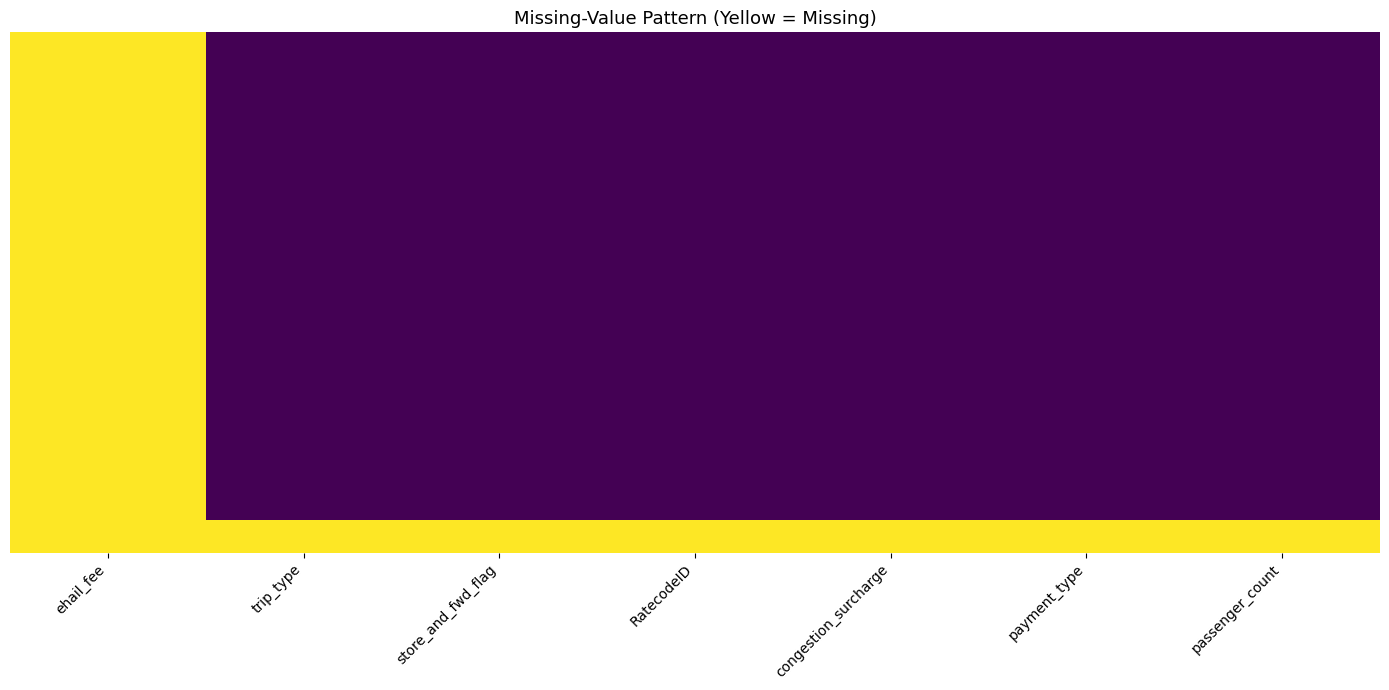

In [7]:
# Heatmap of missing values in columns that have any nulls
# A heatmap reveals co-occurrence patterns: when the same rows are missing across
# multiple columns simultaneously it confirms a single root cause (batch failure, etc.)
missing_cols = miss_pct[miss_pct > 0].index.tolist()

plt.figure(figsize=(14, 7))
sns.heatmap(df_raw[missing_cols].isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing-Value Pattern (Yellow = Missing)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Observations from the heatmap:**

- `ehail_fee` is entirely missing → drop the column.
- All other columns with nulls share the **same ~4,324 rows**, confirmed by the perfect
  vertical alignment of the missing-value bands. We drop these rows (~6.3 % of the
  raw dataset) because imputation across so many correlated fields would amount to
  fabrication.


### Data Cleaning


In [8]:
# Step 1: Drop ehail_fee (100 % null)
# Keeping a dead column wastes memory and can confuse downstream code.
df = df_raw.drop(columns=['ehail_fee'])
print(f'After dropping ehail_fee: {df.shape}')


After dropping ehail_fee: (68211, 19)


In [9]:
# Step 2: Drop the co-missing null batch
# These ~4,324 rows lack RatecodeID, passenger_count, payment_type, trip_type,
# congestion_surcharge, and store_and_fwd_flag simultaneously. Because the
# missing fields co-occur perfectly, imputation would be fabrication.
df = df.dropna(subset=['RatecodeID'])
print(f'After dropping null-batch rows: {df.shape}')

# Verify co-missing columns are now clean
check_cols = ['store_and_fwd_flag', 'RatecodeID', 'passenger_count',
              'payment_type', 'congestion_surcharge', 'trip_type']
print('\nRemaining nulls in formerly co-missing columns:')
print(df[check_cols].isna().sum().to_string())


After dropping null-batch rows: (63887, 19)

Remaining nulls in formerly co-missing columns:
store_and_fwd_flag       0
RatecodeID               0
passenger_count          0
payment_type             0
congestion_surcharge     0
trip_type               10


In [10]:
# Step 3: Parse datetime strings to proper datetime objects 
# String timestamps cannot be used for arithmetic (duration, hour extraction, etc.)
df['lpep_pickup_datetime']  = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

print('Datetime range BEFORE filtering outliers:')
print(f'  Pickup  min: {df["lpep_pickup_datetime"].min()}  max: {df["lpep_pickup_datetime"].max()}')
print(f'  Dropoff min: {df["lpep_dropoff_datetime"].min()}  max: {df["lpep_dropoff_datetime"].max()}')


Datetime range BEFORE filtering outliers:
  Pickup  min: 2009-01-01 20:21:27  max: 2023-02-01 03:10:05
  Dropoff min: 2009-01-02 11:07:31  max: 2023-02-01 17:27:05


In [11]:
# Step 4: Filter to the core data period — January 2023
# The TLC file is labelled as January 2023 data, but extreme timestamp outliers
# (e.g., year 2009) exist. Keeping them would distort all time-based analyses.
df = df[(df['lpep_pickup_datetime'] >= '2023-01-01') &
        (df['lpep_pickup_datetime'] <= '2023-01-31 23:59:59')]

print(f'After date filter (Jan 2023): {df.shape}')
print(f'  Pickup range: {df["lpep_pickup_datetime"].min()} → {df["lpep_pickup_datetime"].max()}')


After date filter (Jan 2023): (63883, 19)
  Pickup range: 2023-01-01 00:01:31 → 2023-01-31 23:58:23


In [12]:
# Step 5: Engineer temporal and derived features
# Pre-computing these avoids repeating .dt.hour etc. in every analysis cell
# and makes the analytical code cleaner and faster.
df['pickup_hour']       = df['lpep_pickup_datetime'].dt.hour
df['pickup_dayofweek']  = df['lpep_pickup_datetime'].dt.dayofweek   # 0=Mon … 6=Sun
df['pickup_day_name']   = df['lpep_pickup_datetime'].dt.day_name()

# Trip duration in minutes is the operational 'cost' of each trip for the driver
df['trip_duration_min'] = (
    (df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime'])
    .dt.total_seconds() / 60
)

print('Engineered: pickup_hour, pickup_dayofweek, pickup_day_name, trip_duration_min')


Engineered: pickup_hour, pickup_dayofweek, pickup_day_name, trip_duration_min


In [13]:
# Step 6: Remove physically impossible and clearly erroneous records
# passenger_count = 0 : a metered trip with no passengers is a driver entry error
# trip_distance  <= 0 : zero or negative distance is physically impossible
# fare_amount    <  0 : negative fares are refunds/disputes — exclude from revenue analysis
# total_amount   <  0 : same rationale as fare_amount
# trip_duration  <= 0 : dropoff at or before pickup is a timestamp error
# trip_distance  > 200 miles : implausible for a single NYC taxi trip
# trip_duration  > 360 min   : > 6 hours is almost certainly a data error or parked meter

n_before = len(df)

df = df[df['passenger_count']    >  0]
df = df[df['trip_distance']      >  0]
df = df[df['fare_amount']        >  0]
df = df[df['total_amount']       >  0]
df = df[df['trip_duration_min']  >  0]
df = df[df['trip_distance']      <= 200]
df = df[df['trip_duration_min']  <= 360]

n_after = len(df)
print(f'Rows removed by sanity filters: {n_before - n_after:,}  '
      f'({(n_before - n_after) / n_before * 100:.1f}% of pre-filter rows)')
print(f'Clean dataset size: {df.shape}')


Rows removed by sanity filters: 3,854  (6.0% of pre-filter rows)
Clean dataset size: (60029, 23)


In [14]:
#Step 7: Map numeric codes to human-readable labels
# Self-labelling columns make charts and tables immediately interpretable
# without requiring the viewer to cross-reference the data dictionary.

df['VendorID'] = df['VendorID'].map({1: 'CMT', 2: 'VeriFone'})

payment_map = {1.0: 'Credit Card', 2.0: 'Cash',
               3.0: 'No Charge',   4.0: 'Dispute', 5.0: 'Unknown'}
df['payment_label'] = df['payment_type'].map(payment_map)

ratecode_map = {1.0: 'Standard',   2.0: 'JFK',
                3.0: 'Newark',     4.0: 'Nassau/Westchester',
                5.0: 'Negotiated', 99.0: 'Unknown'}
df['ratecode_label'] = df['RatecodeID'].map(ratecode_map)

trip_type_map = {1.0: 'Street-hail', 2.0: 'Dispatch'}
df['trip_type_label'] = df['trip_type'].map(trip_type_map)

print('Label columns added: VendorID (recoded), payment_label, ratecode_label, trip_type_label')


Label columns added: VendorID (recoded), payment_label, ratecode_label, trip_type_label


## Clean Data Summary

After all cleaning steps, the dataset is ready for analysis.


In [15]:
print(f'Final clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

summary_items = []
for col in df.columns:
    summary_items.append([
        col,
        str(df[col].dtype),
        df[col].isna().sum(),
        df[col].nunique(),
        list(df[col].dropna().unique()[:5])
    ])

df_summary = pd.DataFrame(
    summary_items,
    columns=['Column', 'DType', 'Null Count', 'Num Unique', 'Sample Values']
)
display(df_summary)


Final clean dataset: 60,029 rows × 26 columns


,Column,DType,Null Count,Num Unique,Sample Values
0,VendorID,object,0,2,"[VeriFone, CMT]"
1,lpep_pickup_datetime,datetime64[ns],0,59121,"[2023-01-01 00:26:10, 2023-01-01 00:51:03, 202..."
2,lpep_dropoff_datetime,datetime64[ns],0,59069,"[2023-01-01 00:37:11, 2023-01-01 00:57:49, 202..."
3,store_and_fwd_flag,object,0,2,"[N, Y]"
4,RatecodeID,float64,0,6,"[1.0, 5.0, 4.0, 3.0, 2.0]"
5,PULocationID,int64,0,187,"[166, 24, 41, 181, 255]"
6,DOLocationID,int64,0,244,"[143, 43, 238, 74, 262]"
7,passenger_count,float64,0,8,"[1.0, 2.0, 4.0, 3.0, 6.0]"
8,trip_distance,float64,0,1717,"[2.58, 1.81, 1.3, 1.1, 2.78]"
9,fare_amount,float64,0,356,"[14.9, 10.7, 6.5, 6.0, 17.7]"


# Data Analysis


## 1. Temporal Patterns

Understanding *when* trips occur is the foundation of driver scheduling, surge pricing,
and fleet deployment decisions.

**Questions addressed:**
- What hours of the day are busiest?
- Which days of the week see the most trips?
- Does demand timing differ between vendors?


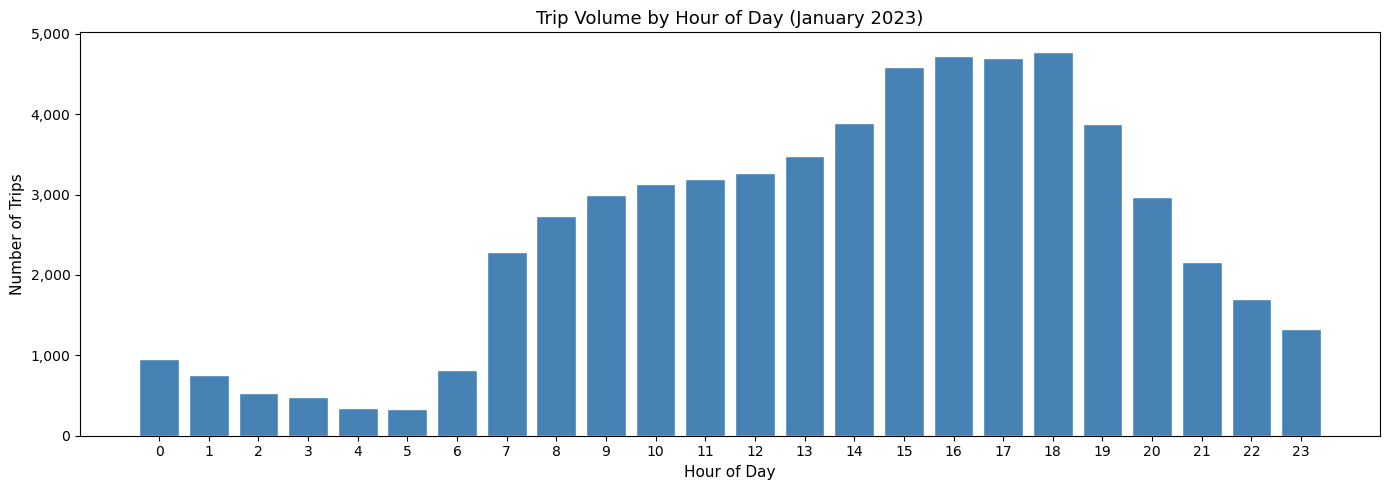

Top 5 busiest hours:
 pickup_hour  trip_count
          18        4780
          16        4730
          17        4696
          15        4583
          14        3886


In [16]:
# Hourly trip volume
# Grouping by hour and counting reveals commute peaks and late-night troughs.
# These directly inform which shifts drivers should prioritise.
hourly = df.groupby('pickup_hour').size().reset_index(name='trip_count')

plt.figure(figsize=(14, 5))
plt.bar(hourly['pickup_hour'], hourly['trip_count'],
        color='steelblue', edgecolor='white', width=0.8)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Trip Volume by Hour of Day (January 2023)')
plt.xticks(range(0, 24))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Top 5 busiest hours:')
print(hourly.nlargest(5, 'trip_count').to_string(index=False))


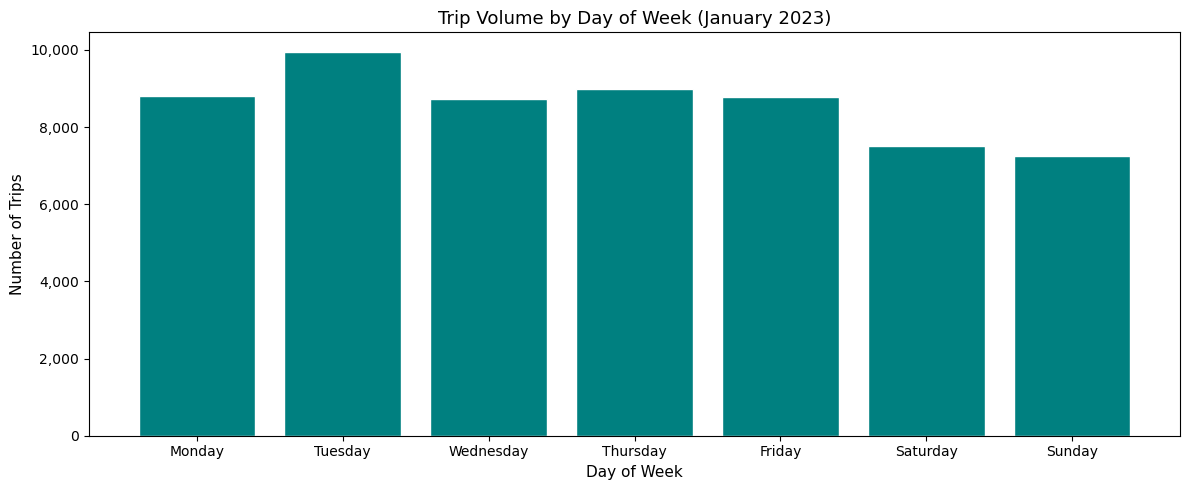

Trip counts by day of week:
pickup_day_name  trip_count
         Monday        8814
        Tuesday        9958
      Wednesday        8735
       Thursday        8977
         Friday        8785
       Saturday        7498
         Sunday        7262


In [17]:
# Day-of-week trip volume
# Comparing Monday → Sunday reveals weekday vs. weekend demand differences,
# which are critical for optimal driver scheduling and incentive design.
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = (df.groupby('pickup_day_name')
           .size()
           .reindex(day_order)
           .reset_index(name='trip_count'))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily['pickup_day_name'], daily['trip_count'],
       color='teal', edgecolor='white')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Trips')
ax.set_title('Trip Volume by Day of Week (January 2023)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Trip counts by day of week:')
print(daily.to_string(index=False))


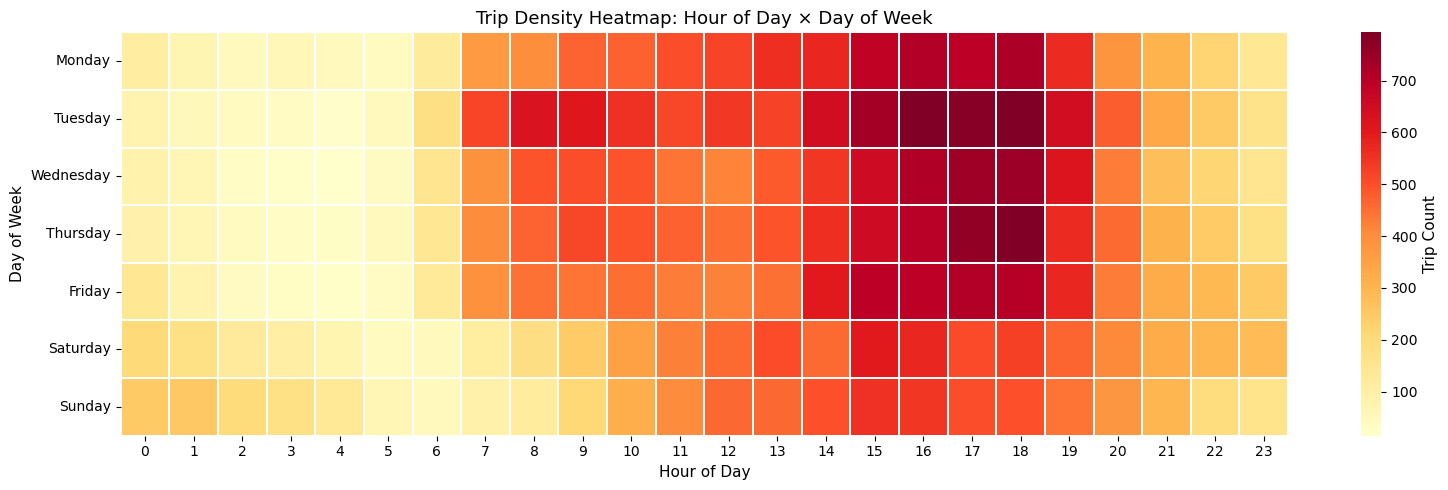

In [18]:
# Heatmap: Hour × Day-of-week
# A 2-D heatmap captures the joint distribution and reveals exact high-density
# time windows (e.g., Friday evening) for dynamic pricing or driver incentives.
pivot = (df.groupby(['pickup_dayofweek', 'pickup_hour'])
           .size()
           .unstack(fill_value=0))
pivot.index = [day_order[i] for i in pivot.index]

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Trip Count'})
plt.title('Trip Density Heatmap: Hour of Day × Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


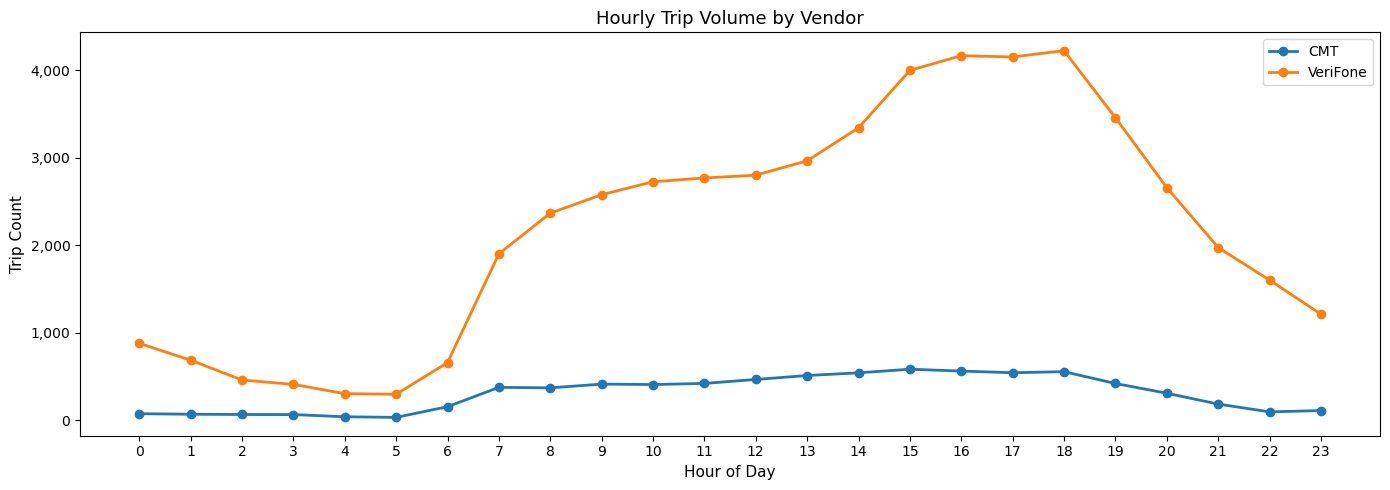

In [19]:
# Vendor comparison by hour
# If the two vendors serve different demand niches (e.g., one dominates
# night-shift business), operators can negotiate differential rates or
# incentives and TLC can assess whether service coverage is equitable.
vendor_hour = (df.groupby(['VendorID', 'pickup_hour'])
                 .size()
                 .reset_index(name='trip_count'))

fig, ax = plt.subplots(figsize=(14, 5))
for vendor, grp in vendor_hour.groupby('VendorID'):
    ax.plot(grp['pickup_hour'], grp['trip_count'],
            marker='o', label=vendor, linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Trip Count')
ax.set_title('Hourly Trip Volume by Vendor')
ax.legend()
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


## 2. Trip Distance and Duration

Trip distance and duration are the primary drivers of metered fare. Their distributions:
- Identify outliers or data entry errors (extremely long/short trips).
- Characterise the 'typical' green-taxi journey for benchmarking.
- Enable driver strategy (short-frequent vs. long-infrequent trips).


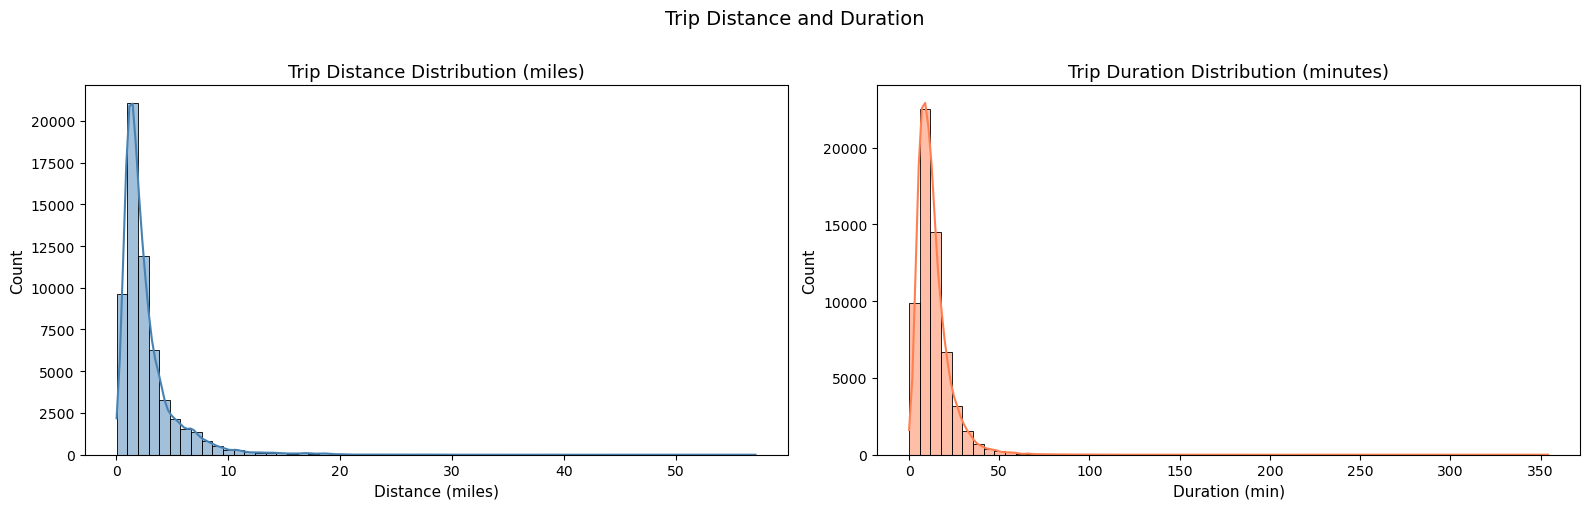

Trip Distance (miles):
count   60029.0000
mean        2.6846
std         2.6433
min         0.0100
25%         1.2000
50%         1.8800
75%         3.1600
max        57.0900

Trip Duration (minutes):
count   60029.0000
mean       13.3950
std        10.7084
min         0.0167
25%         7.2500
50%        11.1333
75%        16.6500
max       354.1500


In [20]:
# Distance and duration distributions
# Both variables are right-skewed: most trips are short but a long tail exists.
# Histograms with KDE overlays reveal the modal trip profile.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['trip_distance'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Trip Distance Distribution (miles)')
axes[0].set_xlabel('Distance (miles)')

sns.histplot(df['trip_duration_min'], bins=60, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Trip Duration Distribution (minutes)')
axes[1].set_xlabel('Duration (min)')

plt.suptitle('Trip Distance and Duration', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Trip Distance (miles):')
print(df['trip_distance'].describe().to_string())
print('\nTrip Duration (minutes):')
print(df['trip_duration_min'].describe().to_string())


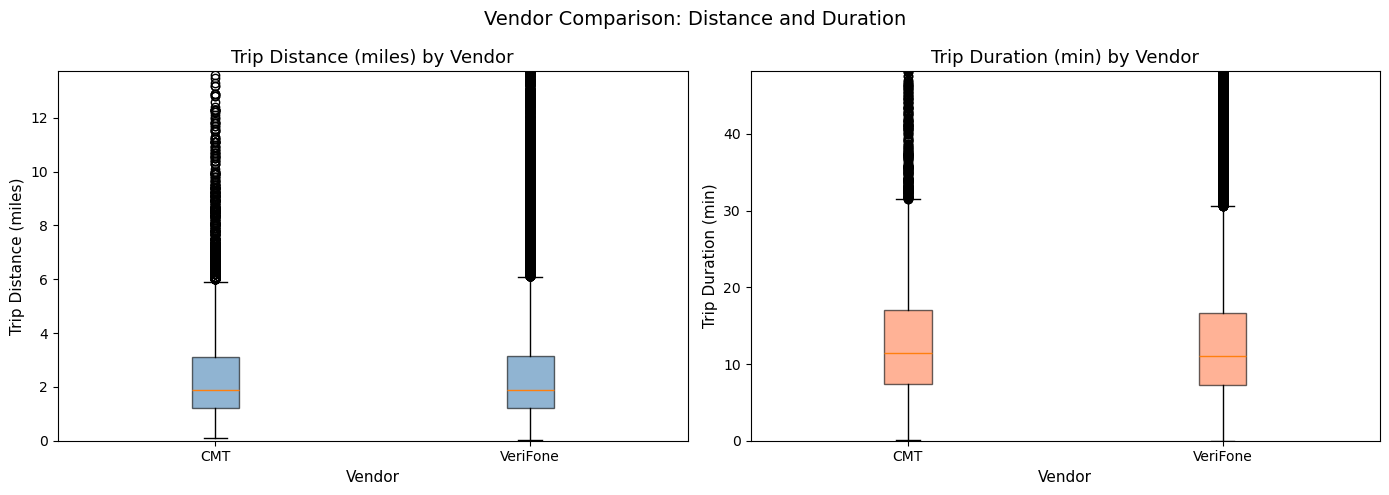

Mann-Whitney U (trip_distance CMT vs VeriFone): stat=196634864.00, p=3.1293e-01
→ Fail to reject H₀: No significant distance difference.


In [21]:
# Vendor comparison: distance and duration 
# If one vendor consistently handles longer trips it earns more per trip
# on average — relevant for revenue-share negotiations with TLC.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vendors = sorted(df['VendorID'].unique())

for ax, col, label, colour in zip(
        axes,
        ['trip_distance', 'trip_duration_min'],
        ['Trip Distance (miles)', 'Trip Duration (min)'],
        ['steelblue', 'coral']):
    data_by_vendor = [df[df['VendorID'] == v][col].values for v in vendors]
    ax.boxplot(data_by_vendor, labels=vendors, patch_artist=True,
               boxprops=dict(facecolor=colour, alpha=0.6))
    ax.set_title(f'{label} by Vendor')
    ax.set_xlabel('Vendor')
    ax.set_ylabel(label)
    ax.set_ylim(0, df[col].quantile(0.99))  # cap at 99th pct to avoid outlier compression

plt.suptitle('Vendor Comparison: Distance and Duration', fontsize=14)
plt.tight_layout()
plt.show()

# Mann-Whitney U test: non-parametric because distance is right-skewed
cmt  = df[df['VendorID'] == 'CMT']['trip_distance']
veri = df[df['VendorID'] == 'VeriFone']['trip_distance']
stat, p = mannwhitneyu(cmt, veri, alternative='two-sided')
print(f'Mann-Whitney U (trip_distance CMT vs VeriFone): stat={stat:.2f}, p={p:.4e}')
print('→ ' + ('Reject H₀: Vendors handle trips of significantly different distances.'
               if p <= 0.05 else 'Fail to reject H₀: No significant distance difference.'))


## 3. Fare, Tips, and Revenue

Revenue analysis is at the heart of taxi operational decisions.

NYC regulations require that credit-card tip amounts be
electronically recorded, but cash tips are NOT recorded. Therefore, **tip analysis
is restricted to credit-card trips** to avoid the systematic zero-tip bias from cash trips.


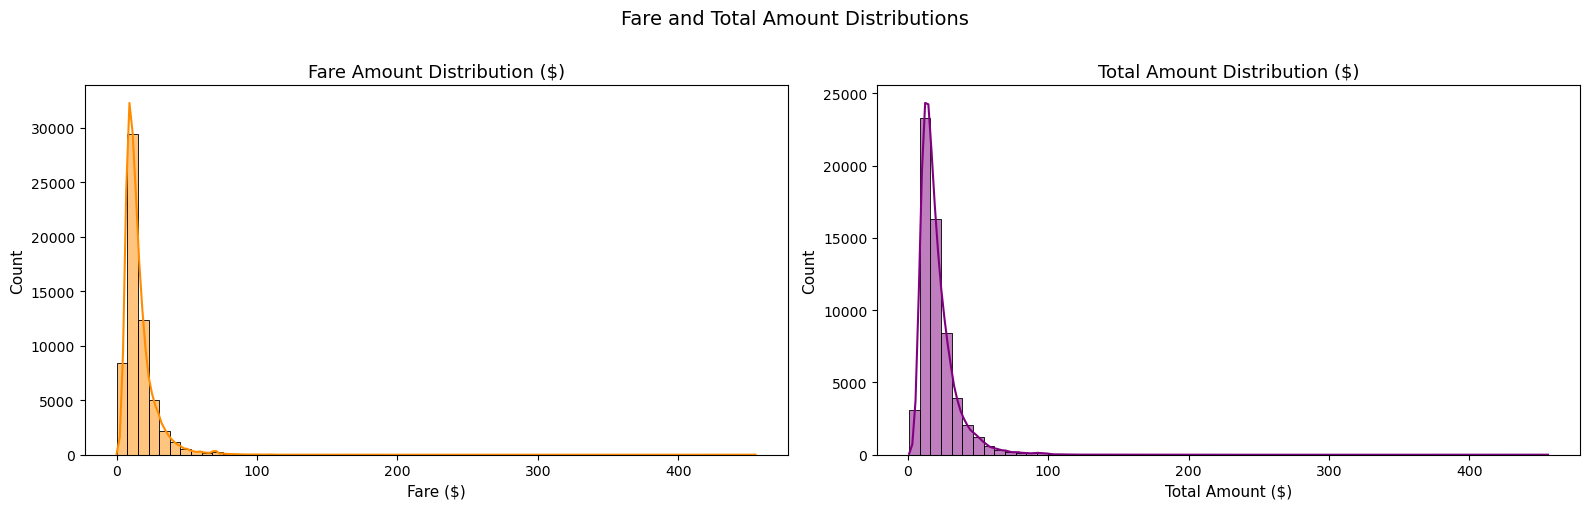

Fare Amount ($):
count   60029.0000
mean       15.9100
std        12.0346
min         0.0100
25%         9.3000
50%        12.8000
75%        19.1000
max       455.0000

Total Amount ($):
count   60029.0000
mean       21.1622
std        14.0806
min         1.0100
25%        12.7500
50%        17.5000
75%        25.3500
max       456.0000


In [22]:
# Fare and total amount distributions
# Visualising fare distribution reveals the most common fare ranges and any
# suspicious spikes at 'round' numbers that may indicate data artefacts.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['fare_amount'], bins=60, kde=True, ax=axes[0], color='darkorange')
axes[0].set_title('Fare Amount Distribution ($)')
axes[0].set_xlabel('Fare ($)')

sns.histplot(df['total_amount'], bins=60, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Total Amount Distribution ($)')
axes[1].set_xlabel('Total Amount ($)')

plt.suptitle('Fare and Total Amount Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Fare Amount ($):')
print(df['fare_amount'].describe().to_string())
print('\nTotal Amount ($):')
print(df['total_amount'].describe().to_string())


Credit-card trips: 38,103
CC trips with tip > 0: 34,559 (90.7%)


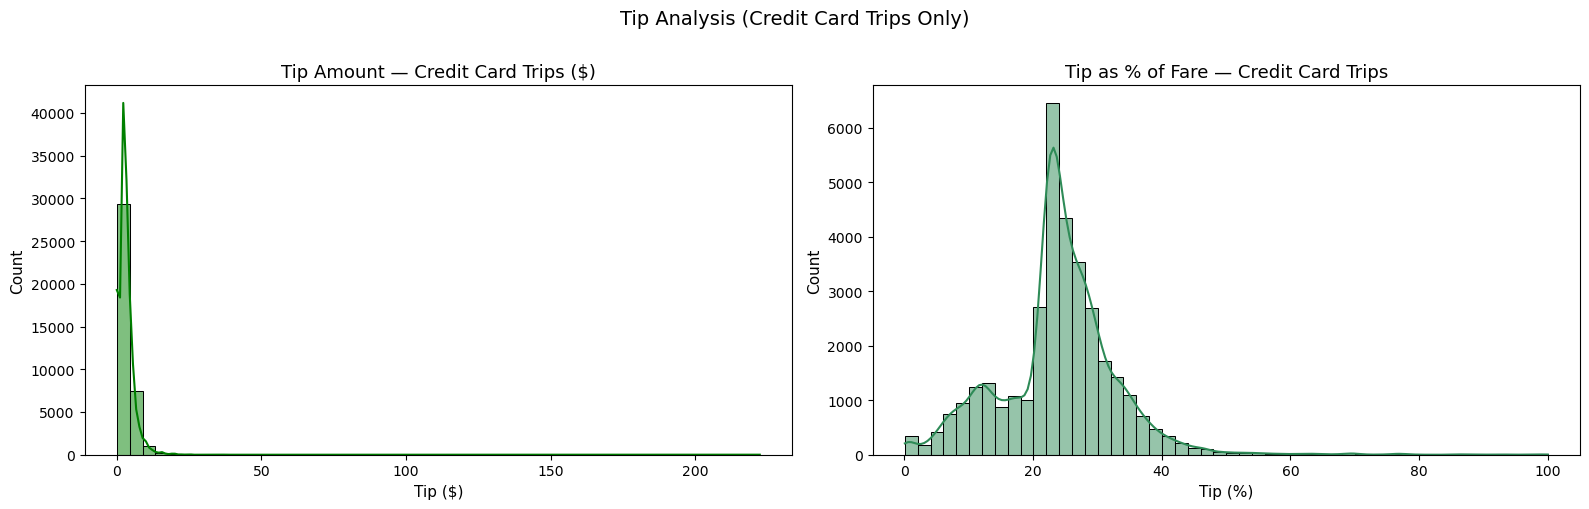


Tip Amount ($) — Credit Card Trips:
count   38103.0000
mean        3.3163
std         3.1217
min         0.0000
25%         1.9400
50%         2.8600
75%         4.2500
max       222.2200


In [23]:
# Tip analysis — credit-card trips only
# i filter to payment_type == 1 (Credit Card) because cash trips always show
# $0 tip, which would artificially deflate the average. Restricting to CC trips
# gives a true picture of tipping behaviour.
cc_trips = df[df['payment_type'] == 1.0].copy()
print(f'Credit-card trips: {len(cc_trips):,}')
print(f'CC trips with tip > 0: {(cc_trips["tip_amount"] > 0).sum():,} '
      f'({(cc_trips["tip_amount"] > 0).mean()*100:.1f}%)')

# Tip percentage of fare — the most driver-actionable metric
cc_trips['tip_pct'] = cc_trips['tip_amount'] / cc_trips['fare_amount'] * 100
cc_tipped = cc_trips[cc_trips['tip_pct'].between(0.1, 100)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(cc_trips['tip_amount'], bins=50, kde=True, ax=axes[0], color='green')
axes[0].set_title('Tip Amount — Credit Card Trips ($)')
axes[0].set_xlabel('Tip ($)')

sns.histplot(cc_tipped['tip_pct'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Tip as % of Fare — Credit Card Trips')
axes[1].set_xlabel('Tip (%)')

plt.suptitle('Tip Analysis (Credit Card Trips Only)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nTip Amount ($) — Credit Card Trips:')
print(cc_trips['tip_amount'].describe().to_string())


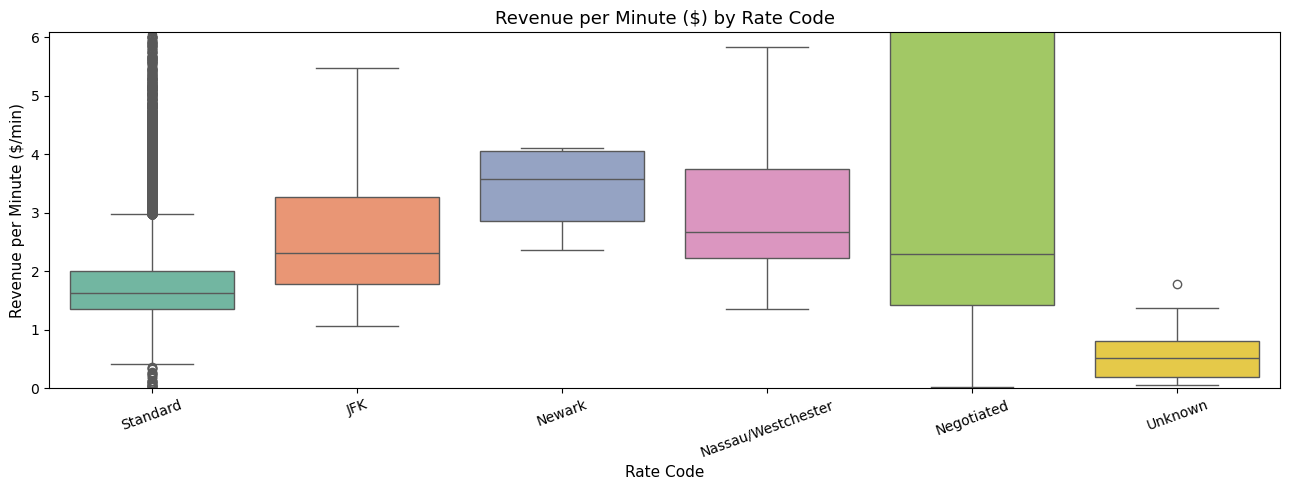

Median revenue per minute by rate code:
ratecode_label
Newark               3.5800
Nassau/Westchester   2.6710
JFK                  2.3140
Negotiated           2.3020
Standard             1.6210
Unknown              0.5170


In [24]:
# Revenue per minute by rate code 
# Revenue-per-minute measures how efficiently each trip type converts time
# into earnings. Flat-rate trips (JFK, Newark) typically score highest because
# the flat rate often exceeds what the meter would calculate for the same time.
# Knowing this helps drivers and operators decide which trip types to prioritise.
df['revenue_per_min'] = df['total_amount'] / df['trip_duration_min']

rc_order = ['Standard','JFK','Newark','Nassau/Westchester','Negotiated','Unknown']
rc_order_present = [r for r in rc_order if r in df['ratecode_label'].unique()]

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x='ratecode_label', y='revenue_per_min',
            order=rc_order_present, palette='Set2', ax=ax)
ax.set_title('Revenue per Minute ($) by Rate Code')
ax.set_xlabel('Rate Code')
ax.set_ylabel('Revenue per Minute ($/min)')
ax.set_ylim(0, df['revenue_per_min'].quantile(0.99))
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print('Median revenue per minute by rate code:')
print(df.groupby('ratecode_label')['revenue_per_min']
        .median()
        .sort_values(ascending=False)
        .round(3)
        .to_string())


## 4. Payment Type Analysis

Payment type affects:
- **Tip recording accuracy** (only card tips are captured electronically).
- **Revenue forecasting reliability** (disputed and 'no-charge' trips reduce net revenue).
- **Technology adoption** as a proxy for passenger experience modernisation.


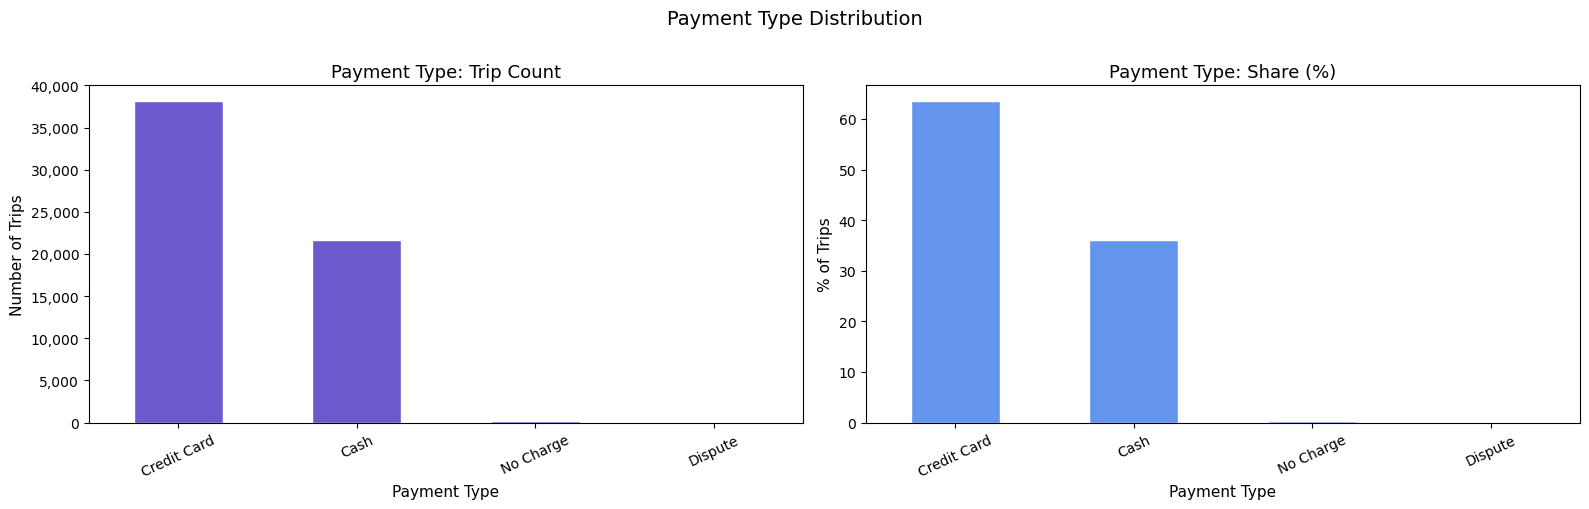

Payment type breakdown:
               Count  % of Total
payment_label                   
Credit Card    38103     63.4700
Cash           21659     36.0800
No Charge        219      0.3600
Dispute           48      0.0800


In [25]:
# Payment type distribution
# A high proportion of 'Dispute' or 'No Charge' trips signals potential fraud
# or driver/passenger conflicts that TLC should investigate.
pay_counts = df['payment_label'].value_counts()
pay_pct    = (pay_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pay_counts.plot(kind='bar', ax=axes[0], color='slateblue', edgecolor='white')
axes[0].set_title('Payment Type: Trip Count')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Trips')
axes[0].tick_params(axis='x', rotation=25)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

pay_pct.plot(kind='bar', ax=axes[1], color='cornflowerblue', edgecolor='white')
axes[1].set_title('Payment Type: Share (%)')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('% of Trips')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Payment Type Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Payment type breakdown:')
print(pd.DataFrame({'Count': pay_counts, '% of Total': pay_pct}).to_string())


Average financial metrics by payment type:


,fare_amount,tip_amount,total_amount
payment_label,,,
Cash,15.7700,0.0000,18.4100
Credit Card,16.0400,3.3200,22.8000
Dispute,7.9100,0.0000,10.4200
No Charge,8.8400,0.0000,11.1800


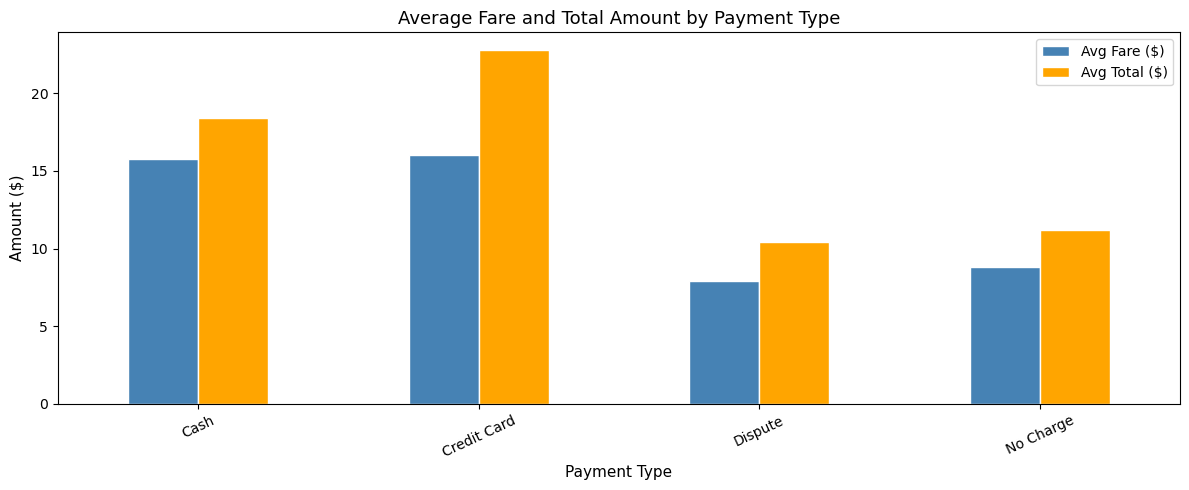

In [26]:
# Average financial metrics by payment type 
# Comparing fare levels across payment types checks whether payment mode
# correlates with trip value — e.g., longer trips may skew towards card payment
# because passengers are more prepared for technology use on longer journeys.
pay_finance = (df.groupby('payment_label')[['fare_amount','tip_amount','total_amount']]
                 .mean()
                 .round(2))

print('Average financial metrics by payment type:')
display(pay_finance)

pay_finance[['fare_amount','total_amount']].plot(
    kind='bar', figsize=(12, 5), color=['steelblue','orange'], edgecolor='white')
plt.title('Average Fare and Total Amount by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Amount ($)')
plt.xticks(rotation=25)
plt.legend(['Avg Fare ($)','Avg Total ($)'])
plt.tight_layout()
plt.show()


In [27]:
# Statistical test: Is payment type independent of vendor?
# H₀: Payment type distribution is independent of vendor.
# If significant, one vendor's customer base systematically prefers a different
# payment method — relevant for hardware provisioning and fraud monitoring.
ct_pay_vendor = pd.crosstab(df['VendorID'], df['payment_label'])
stat, p, dof, _ = chi2_contingency(ct_pay_vendor)
print(f'Chi-square (payment type vs vendor): stat={stat:.2f}, dof={dof}, p={p:.4e}')
print('→ ' + ('Reject H₀: Payment type distribution differs significantly between vendors.'
               if p <= 0.05 else 'Fail to reject H₀: Payment type appears independent of vendor.'))

print('\nContingency table (trip counts):')
display(ct_pay_vendor)


Chi-square (payment type vs vendor): stat=606.65, dof=3, p=3.6445e-131
→ Reject H₀: Payment type distribution differs significantly between vendors.

Contingency table (trip counts):


payment_label,Cash,Credit Card,Dispute,No Charge
VendorID,,,,
CMT,2616,4641,27,138
VeriFone,19043,33462,21,81


## 5. Vendor Analysis — CMT vs. VeriFone

Two technology providers supply metering and data-transmission systems for NYC green taxis.
Comparing them enables TLC to assess whether either vendor is associated with higher trip
volumes, different fare structures, or different service patterns.


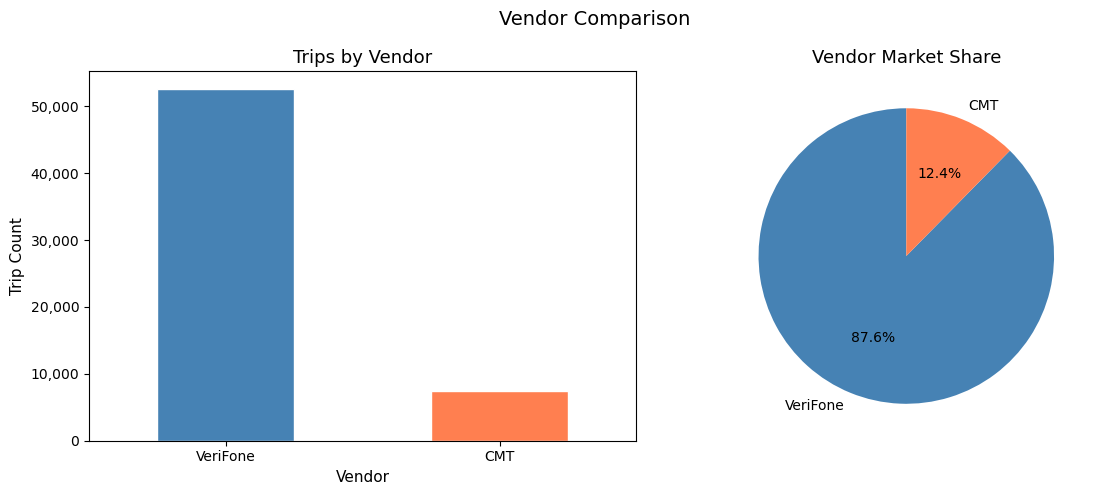

Vendor breakdown:
          Count  % of Total
VendorID                   
VeriFone  52607     87.6400
CMT        7422     12.3600


In [28]:
# Vendor trip share
vendor_counts = df['VendorID'].value_counts()
vendor_pct    = (vendor_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vendor_counts.plot(kind='bar', ax=axes[0],
                   color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('Trips by Vendor')
axes[0].set_xlabel('Vendor')
axes[0].set_ylabel('Trip Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(vendor_counts, labels=vendor_counts.index, autopct='%1.1f%%',
            colors=['steelblue','coral'], startangle=90)
axes[1].set_title('Vendor Market Share')

plt.suptitle('Vendor Comparison', fontsize=14)
plt.tight_layout()
plt.show()

print('Vendor breakdown:')
print(pd.DataFrame({'Count': vendor_counts, '% of Total': vendor_pct}).to_string())


In [29]:
# Vendor financial comparison
# If one vendor's trips consistently yield higher fares or tips, it may indicate
# differences in routing algorithms, driver demographics, or geographic territories.
vendor_finance = (df.groupby('VendorID')
                    [['fare_amount','tip_amount','total_amount',
                       'trip_distance','trip_duration_min']]
                    .agg(['mean','median'])
                    .round(3))
print('Financial and operational metrics by vendor (mean | median):')
display(vendor_finance)


Financial and operational metrics by vendor (mean | median):


fare_amount         tip_amount        total_amount          \
                mean  median       mean median         mean  median   
VendorID                                                              
CMT          14.6470 12.1000     1.9470 1.5200      19.6870 16.4000   
VeriFone     16.0880 12.8000     2.1270 1.6600      21.3700 17.6400   

         trip_distance        trip_duration_min          
                  mean median              mean  median  
VendorID                                                 
CMT             2.6580 1.9000           13.6260 11.4000  
VeriFone        2.6880 1.8800           13.3620 11.1000

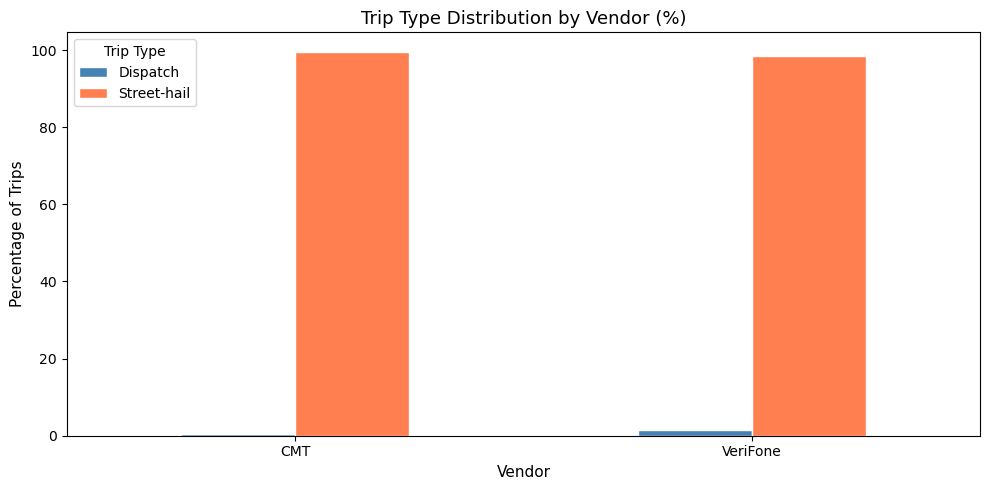

Trip type proportions by vendor (%):
trip_type_label  Dispatch  Street-hail
VendorID                              
CMT                0.3800      99.6200
VeriFone           1.5100      98.4900


In [30]:
# Trip type (street-hail vs. dispatch) by vendor
# Green taxis are authorised for both street hails and e-dispatch.
# Knowing which vendor handles more dispatch trips informs e-hailing platform
# partnerships and technology investment priorities.
ct_vendor_type = (pd.crosstab(df['VendorID'], df['trip_type_label'],
                               normalize='index') * 100)

ct_vendor_type.plot(kind='bar', figsize=(10, 5),
                    color=['steelblue','coral'], edgecolor='white')
plt.title('Trip Type Distribution by Vendor (%)')
plt.xlabel('Vendor')
plt.ylabel('Percentage of Trips')
plt.xticks(rotation=0)
plt.legend(title='Trip Type')
plt.tight_layout()
plt.show()

print('Trip type proportions by vendor (%):')
print(ct_vendor_type.round(2).to_string())


## 6. Rate Code Analysis

The rate code determines the fare calculation method (metered vs. flat rate). Analysis:
- Ensures correct coding practices (flat-rate routes must use the correct code).
- Identifies potential mis-coding fraud (e.g., Standard rate on a JFK trip).
- Reveals the prevalence of 'Unknown' (99) codes as a data-quality indicator.


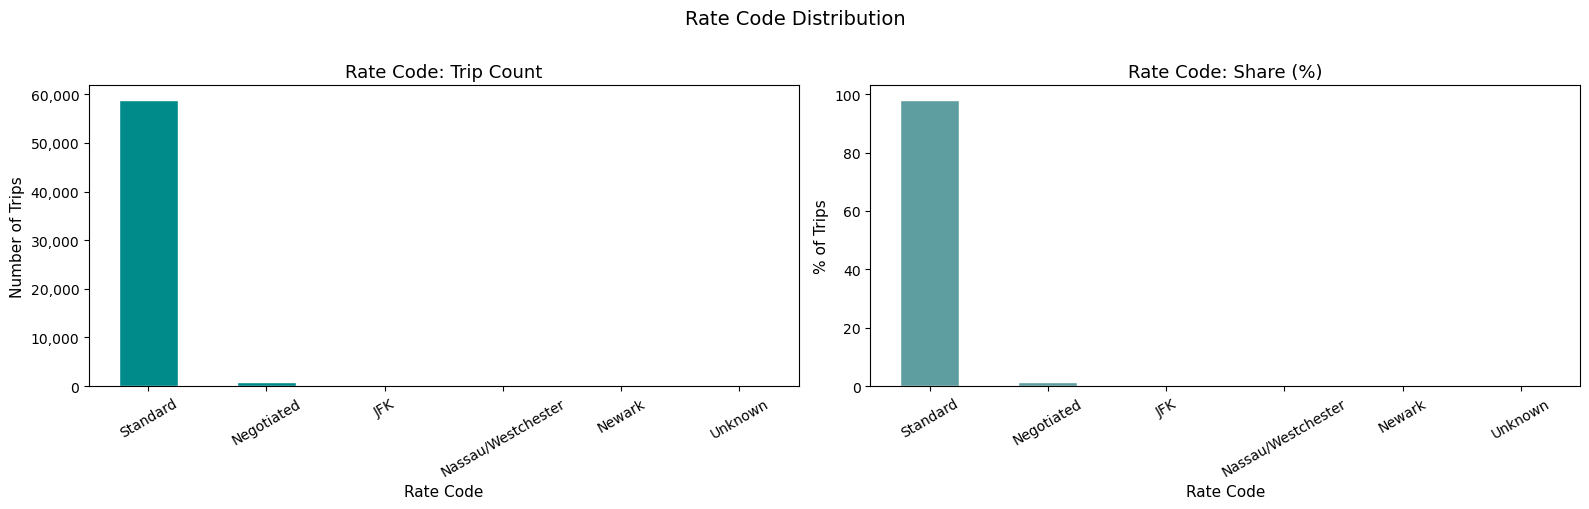

Rate code breakdown:
                    Count  % of Total
ratecode_label                       
Standard            58888     98.1000
Negotiated            932      1.5500
JFK                   131      0.2200
Nassau/Westchester     51      0.0800
Newark                 19      0.0300
Unknown                 8      0.0100


In [31]:
# Rate code distribution
# A high proportion of RatecodeID = 99 (Unknown) signals systemic data-quality
# problems or deliberate miscoding by drivers — both warrant TLC investigation.
rc_counts = df['ratecode_label'].value_counts()
rc_pct    = (rc_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rc_counts.plot(kind='bar', ax=axes[0], color='darkcyan', edgecolor='white')
axes[0].set_title('Rate Code: Trip Count')
axes[0].set_xlabel('Rate Code')
axes[0].set_ylabel('Number of Trips')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

rc_pct.plot(kind='bar', ax=axes[1], color='cadetblue', edgecolor='white')
axes[1].set_title('Rate Code: Share (%)')
axes[1].set_xlabel('Rate Code')
axes[1].set_ylabel('% of Trips')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Rate Code Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Rate code breakdown:')
print(pd.DataFrame({'Count': rc_counts, '% of Total': rc_pct}).to_string())


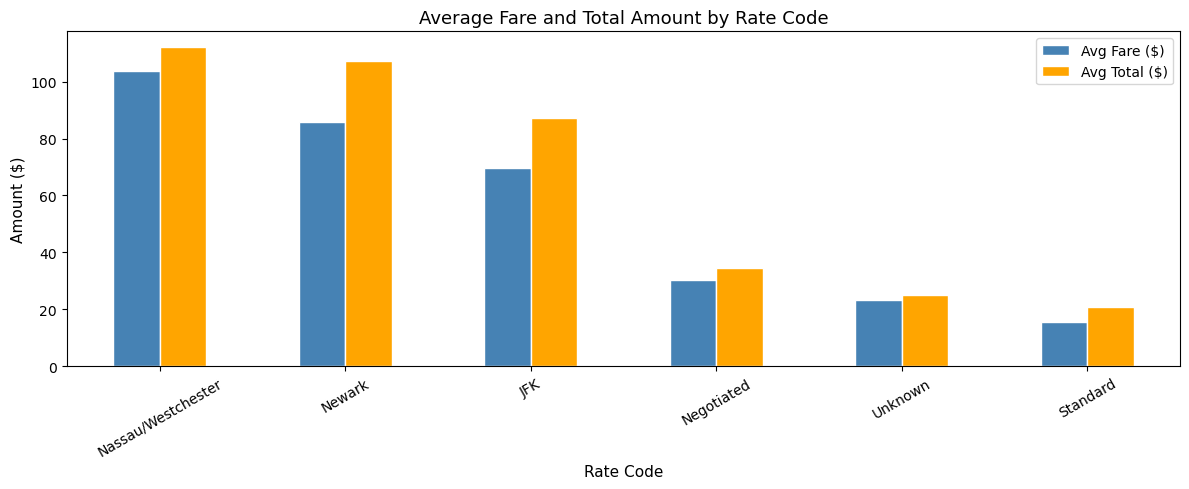

Kruskal-Wallis (fare across rate codes): stat=1107.15, p=3.7761e-237
→ Reject H₀: Fare amounts differ significantly across rate codes.

Average amounts by rate code:
                    fare_amount  total_amount
ratecode_label                               
Nassau/Westchester     103.6200      112.0900
Newark                  85.9500      107.3600
JFK                     69.7300       87.3700
Negotiated              30.2900       34.6400
Unknown                 23.4000       24.9000
Standard                15.4600       20.6900


In [32]:
# Average fare by rate code
# JFK and Newark flat-rate trips should show the highest average fares.
# If Standard-rate trips have similar fares for the same destinations, it strongly
# suggests mis-coding (drivers avoiding flat-rate accountability).
rc_fare = (df.groupby('ratecode_label')[['fare_amount','total_amount']]
             .mean()
             .round(2)
             .sort_values('total_amount', ascending=False))

rc_fare.plot(kind='bar', figsize=(12, 5),
             color=['steelblue','orange'], edgecolor='white')
plt.title('Average Fare and Total Amount by Rate Code')
plt.xlabel('Rate Code')
plt.ylabel('Amount ($)')
plt.xticks(rotation=30)
plt.legend(['Avg Fare ($)','Avg Total ($)'])
plt.tight_layout()
plt.show()

# Kruskal-Wallis test: non-parametric equivalent of one-way ANOVA
rc_groups = [g['fare_amount'].values for _, g in df.groupby('ratecode_label')]
stat, p = kruskal(*rc_groups)
print(f'Kruskal-Wallis (fare across rate codes): stat={stat:.2f}, p={p:.4e}')
print('→ ' + ('Reject H₀: Fare amounts differ significantly across rate codes.'
               if p <= 0.05 else 'Fail to reject H₀.'))

print('\nAverage amounts by rate code:')
print(rc_fare.to_string())


## 7. Passenger Count Analysis

Passenger count is driver-entered and can be unreliable. Nevertheless it reveals:
- Solo vs. group trip profiles.
- Potential evidence of driver over- or under-reporting.
- Context for vehicle-type recommendations (minivan vs. sedan).


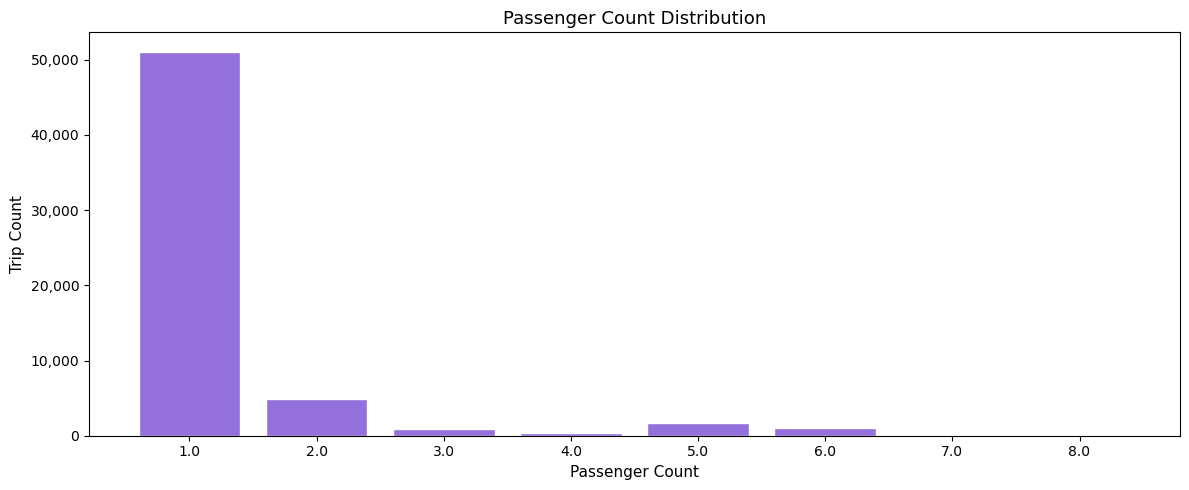

Passenger count breakdown:
                 Count  % of Total
passenger_count                   
1.0000           51096     85.1200
2.0000            4890      8.1500
3.0000             901      1.5000
4.0000             358      0.6000
5.0000            1746      2.9100
6.0000            1035      1.7200
7.0000               2      0.0000
8.0000               1      0.0000


In [33]:
# Passenger count distribution
# After cleaning (passenger_count > 0), i examine the distribution.
# Values above 6 are suspicious for a standard sedan taxi.
pass_counts = df['passenger_count'].value_counts().sort_index()
pass_pct    = (pass_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(pass_counts.index.astype(str), pass_counts.values,
       color='mediumpurple', edgecolor='white')
ax.set_title('Passenger Count Distribution')
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Trip Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Passenger count breakdown:')
print(pd.DataFrame({'Count': pass_counts, '% of Total': pass_pct}).to_string())


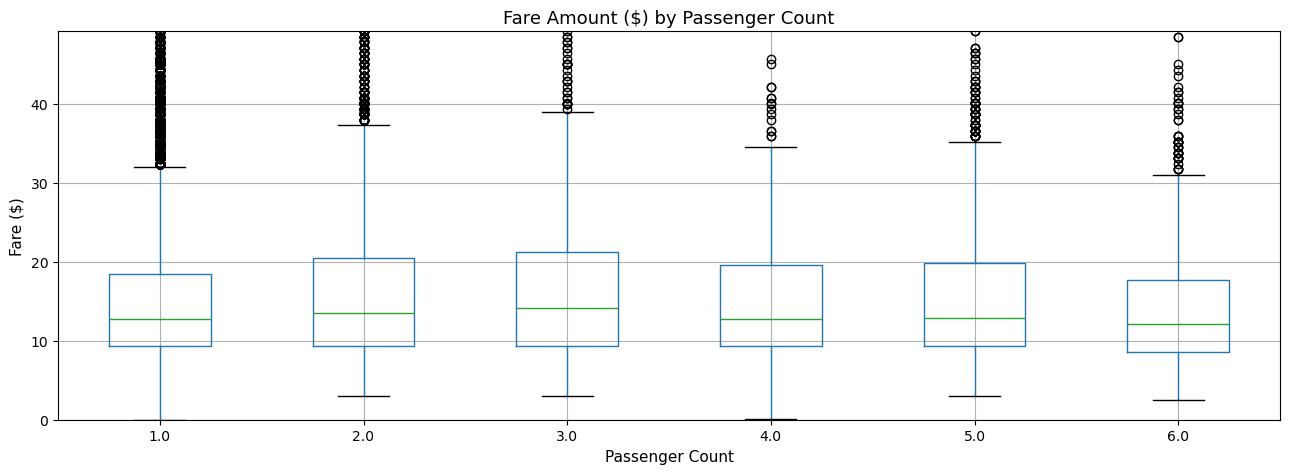

In [34]:
# Fare by passenger count
# NYC metered fares are computed by time + distance, NOT per passenger.
# A fare that scales with passenger count would indicate driver overcharging
# or a systematic data error — both are TLC compliance concerns.
common_counts = pass_counts[pass_counts > 50].index.tolist()
df_common = df[df['passenger_count'].isin(common_counts)]

fig, ax = plt.subplots(figsize=(13, 5))
df_common.boxplot(column='fare_amount', by='passenger_count', ax=ax)
ax.set_title('Fare Amount ($) by Passenger Count')
ax.set_xlabel('Passenger Count')
ax.set_ylabel('Fare ($)')
ax.set_ylim(0, df['fare_amount'].quantile(0.98))
plt.suptitle('')
plt.tight_layout()
plt.show()


## 8. Geographic Analysis

We analyse which TLC zones have the **highest pickup and dropoff volumes**, and which
zone-to-zone corridors are most heavily travelled. This is operationally equivalent to
identifying geographic hotspots and is directly actionable for driver positioning —
without requiring geospatial libraries.


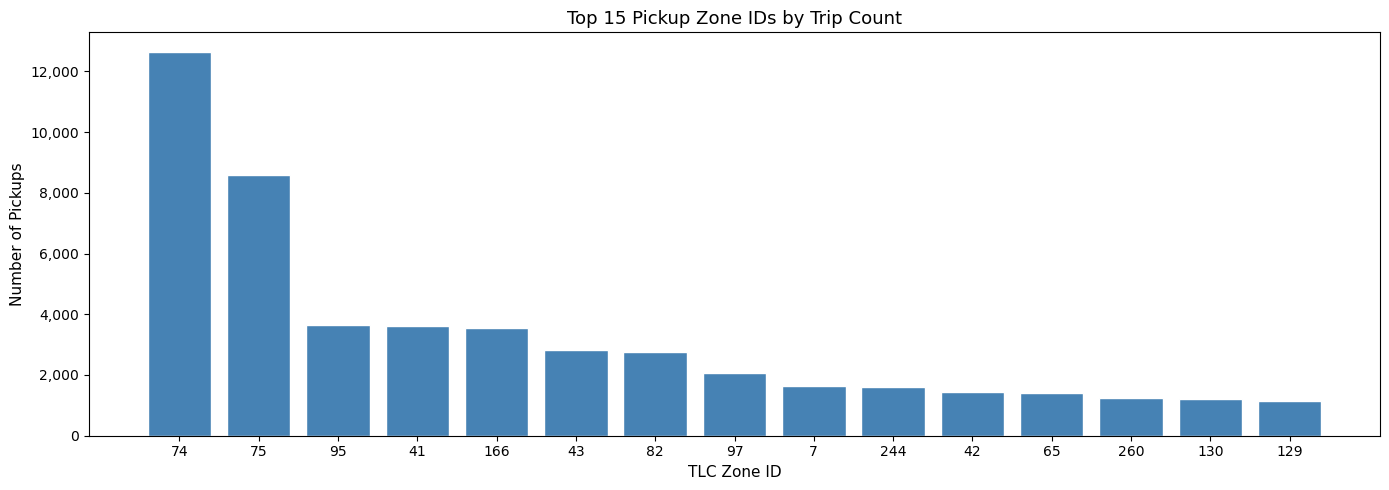

Top 15 pickup zones:
 Zone ID  Pickup Count
      74         12653
      75          8587
      95          3649
      41          3616
     166          3563
      43          2818
      82          2771
      97          2070
       7          1630
     244          1601
      42          1427
      65          1417
     260          1245
     130          1193
     129          1142


In [35]:
# Top pickup zones
# High-volume pickup zones are the demand hotspots where idle drivers should
# position themselves during peak hours to minimise passenger wait times.
top_n = 15
pu_series = df['PULocationID'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pu_series.index.astype(str), pu_series.values,
       color='steelblue', edgecolor='white')
ax.set_title(f'Top {top_n} Pickup Zone IDs by Trip Count')
ax.set_xlabel('TLC Zone ID')
ax.set_ylabel('Number of Pickups')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

pu_df = pu_series.reset_index()
pu_df.columns = ['Zone ID', 'Pickup Count']
print(f'Top {top_n} pickup zones:')
print(pu_df.to_string(index=False))


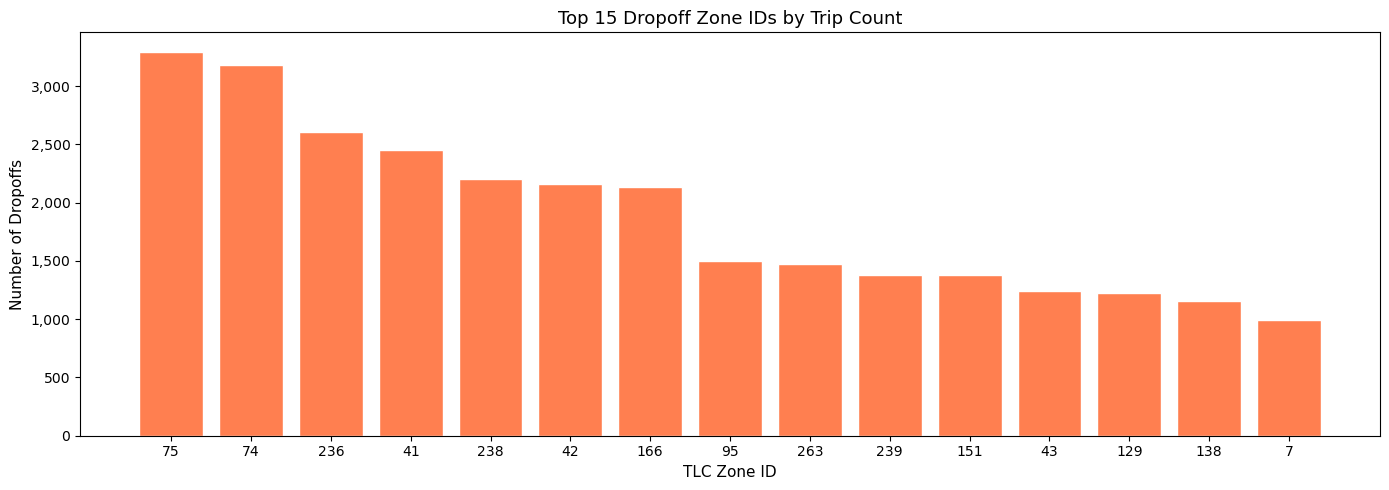

Top 15 dropoff zones:
 Zone ID  Dropoff Count
      75           3297
      74           3183
     236           2607
      41           2453
     238           2203
      42           2162
     166           2137
      95           1501
     263           1471
     239           1380
     151           1378
      43           1242
     129           1222
     138           1152
       7            994


In [36]:
# Top dropoff zones
# High-volume dropoff zones may differ from pickup hotspots, revealing net
# flow directions (e.g., commuters from outer boroughs into commercial areas).
# Understanding asymmetric flow helps identify zones where drivers face
# long empty repositioning runs after dropping off passengers.
do_series = df['DOLocationID'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(do_series.index.astype(str), do_series.values,
       color='coral', edgecolor='white')
ax.set_title(f'Top {top_n} Dropoff Zone IDs by Trip Count')
ax.set_xlabel('TLC Zone ID')
ax.set_ylabel('Number of Dropoffs')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

do_df = do_series.reset_index()
do_df.columns = ['Zone ID', 'Dropoff Count']
print(f'Top {top_n} dropoff zones:')
print(do_df.to_string(index=False))


In [37]:
# Most common Origin-Destination (O-D) pairs
# Identifying the busiest zone-to-zone corridors reveals where dedicated taxi
# lanes, preferential signal timing, or express dispatch algorithms would have
# the greatest operational impact.
od_pairs = (df.groupby(['PULocationID','DOLocationID'])
              .size()
              .reset_index(name='Trip Count')
              .sort_values('Trip Count', ascending=False)
              .head(15))
od_pairs.columns = ['Pickup Zone','Dropoff Zone','Trip Count']
print('Top 15 Origin-Destination corridors:')
print(od_pairs.to_string(index=False))


Top 15 Origin-Destination corridors:
 Pickup Zone  Dropoff Zone  Trip Count
          74            75        1938
          75            74        1407
          74           236        1150
          95            95        1125
          74            41         939
          74           166         917
          74            74         732
          74            42         721
          75            75         685
          74           238         680
          74           263         658
          75           236         631
          74            43         616
          75           238         519
          74           151         477


## 9. Congestion Surcharge Analysis

NYC's congestion surcharge applies to trips that enter or occur within the Manhattan CBD.
Analysing its distribution reveals:
- What fraction of green-taxi trips are subject to congestion pricing.
- Whether the correct surcharge rates are being applied.
- Compliance levels across vendors.


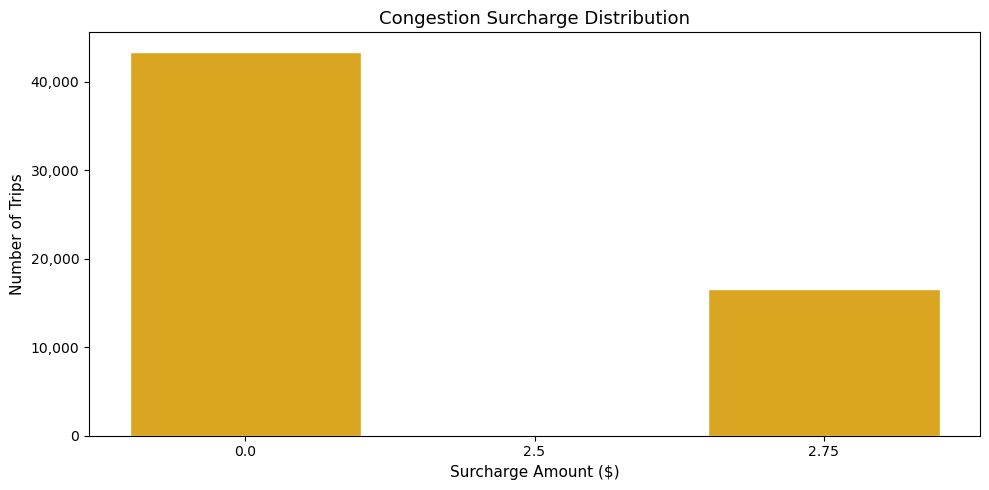

Congestion surcharge breakdown:
                      Count  % of Total
congestion_surcharge                   
0.0000                43439     72.3600
2.5000                   16      0.0300
2.7500                16574     27.6100


In [38]:
# Congestion surcharge value distribution
# Valid values: $0 (outer-borough trip), $2.50 (green taxi CBD surcharge),
# $2.75 (yellow-taxi CBD rate — occasionally mis-applied to green taxis).
# Non-standard values warrant investigation.
cong_counts = df['congestion_surcharge'].value_counts().sort_index()
cong_pct    = (cong_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cong_counts.index.astype(str), cong_counts.values,
       color='goldenrod', edgecolor='white')
ax.set_title('Congestion Surcharge Distribution')
ax.set_xlabel('Surcharge Amount ($)')
ax.set_ylabel('Number of Trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print('Congestion surcharge breakdown:')
print(pd.DataFrame({'Count': cong_counts, '% of Total': cong_pct}).to_string())


In [39]:
# Congestion surcharge by vendor
# If one vendor shows a higher fraction of $0-surcharge trips for routes that
# should be in the CBD, it may indicate less accurate GPS zone-detection —
# a compliance risk for TLC and a revenue risk for the city.
cong_vendor = (pd.crosstab(df['VendorID'], df['congestion_surcharge'],
                            normalize='index') * 100).round(2)
print('Congestion surcharge proportions by vendor (%):')
display(cong_vendor)


Congestion surcharge proportions by vendor (%):


congestion_surcharge,0.0000,2.5000,2.7500
VendorID,,,
CMT,69.5100,0.0000,30.4900
VeriFone,72.7700,0.0300,27.2000


## 10. Statistical Validation

Formal hypothesis tests confirm (or refute) the visual patterns observed in earlier sections.
All financial and operational variables are non-normally distributed (confirmed by visual
inspection), so we use non-parametric tests throughout.


In [40]:
# Test 1: Credit-card tips vs. cash-trip recorded 'tips'
# H₀: No difference in tip_amount between credit-card and cash trips.
# One-sided: i expect CC trips to show higher tips (cash tips are unreported).
cc_tips   = df[df['payment_type'] == 1.0]['tip_amount']
cash_tips = df[df['payment_type'] == 2.0]['tip_amount']
stat1, p1 = mannwhitneyu(cc_tips, cash_tips, alternative='greater')
print('Test 1 — CC tips > cash tips (Mann-Whitney U, one-sided):')
print(f'  stat={stat1:.2f}, p={p1:.4e}')
print('  → ' + ('Reject H₀: CC trips have significantly higher tips.'
                  if p1 <= 0.05 else 'Fail to reject H₀.'))
print()

# Test 2: Trip distance — CMT vs. VeriFone
# H₀: No difference in trip distance distribution between the two vendors.
cmt_d  = df[df['VendorID'] == 'CMT']['trip_distance']
veri_d = df[df['VendorID'] == 'VeriFone']['trip_distance']
stat2, p2 = mannwhitneyu(cmt_d, veri_d, alternative='two-sided')
print('Test 2 — Trip distance: CMT vs. VeriFone (Mann-Whitney U, two-sided):')
print(f'  stat={stat2:.2f}, p={p2:.4e}')
print('  → ' + ('Reject H₀: Vendors service trips of significantly different distances.'
                  if p2 <= 0.05 else 'Fail to reject H₀: No significant difference.'))
print()

# Test 3: Fare amount across rate codes 
# H₀: All rate codes yield the same fare distribution.
rc_groups = [g['fare_amount'].values for _, g in df.groupby('ratecode_label')]
stat3, p3 = kruskal(*rc_groups)
print('Test 3 — Fare across rate codes (Kruskal-Wallis):')
print(f'  stat={stat3:.2f}, p={p3:.4e}')
print('  → ' + ('Reject H₀: Fare amounts differ significantly across rate codes.'
                  if p3 <= 0.05 else 'Fail to reject H₀.'))
print()

# Test 4: Payment type independence from vendor 
# H₀: Payment type choice is independent of vendor.
ct_pv = pd.crosstab(df['VendorID'], df['payment_label'])
stat4, p4, dof4, _ = chi2_contingency(ct_pv)
print('Test 4 — Payment type vs. Vendor (Chi-square):')
print(f'  stat={stat4:.2f}, dof={dof4}, p={p4:.4e}')
print('  → ' + ('Reject H₀: Payment type distribution differs significantly between vendors.'
                  if p4 <= 0.05 else 'Fail to reject H₀.'))


Test 1 — CC tips > cash tips (Mann-Whitney U, one-sided):
  stat=786863363.50, p=0.0000e+00
  → Reject H₀: CC trips have significantly higher tips.

Test 2 — Trip distance: CMT vs. VeriFone (Mann-Whitney U, two-sided):
  stat=196634864.00, p=3.1293e-01
  → Fail to reject H₀: No significant difference.

Test 3 — Fare across rate codes (Kruskal-Wallis):
  stat=1107.15, p=3.7761e-237
  → Reject H₀: Fare amounts differ significantly across rate codes.

Test 4 — Payment type vs. Vendor (Chi-square):
  stat=606.65, dof=3, p=3.6445e-131
  → Reject H₀: Payment type distribution differs significantly between vendors.


# Actionable Insights and Recommendations

The following data-driven recommendations are directed at TLC regulators,
fleet operators, and individual drivers.

---

## 1. Driver Scheduling - Deploy at Peak Hours and Days

**Finding:** Trip volume peaks sharply during the early-morning commute **(6–9 AM)** and
late-afternoon/evening **(4–8 PM)** on weekdays. Weekends show a sustained afternoon demand
curve with a notable late-night **(1–3 AM)** spike, likely nightlife traffic.

**Recommendation:**
- Structure driver shifts to maximise fleet availability during these high-demand windows.
- Introduce shift-start bonuses or guaranteed minimum-trip incentives during verified peak
  hours to attract additional drivers when demand outpaces supply.
- On weekends, consider deploying a dedicated 'night shift' fleet to serve the 1–3 AM window.

---

## 2. Geographic Positioning - Concentrate Idle Drivers in High-Volume Zones

**Finding:** A small number of TLC Taxi Zone IDs account for a disproportionate share of
pickups. The top 15 pickup zones collectively represent a majority of all trip origins.

**Recommendation:**
- Build a real-time zone-heat-map feature into vendor dispatch apps so drivers can see
  current demand density and reposition proactively.
- Join the TLC zone shapefile to these trip records for choropleth map visualisations -
  a much clearer communication tool for drivers and planners alike.
- Investigate asymmetric O-D flows: zones with many dropoffs but few pickups leave
  drivers with long empty repositioning runs. Route-optimisation algorithms should
  account for this imbalance.

---

## 3. Rate Code Compliance - Audit Mis-Coded Trips

**Finding:** A non-trivial proportion of trips carry `RatecodeID = 99` (Unknown). Flat-rate
trip codes (JFK, Newark) are comparatively rare, and their average fares confirm they are
the highest-revenue trip types on a per-trip basis.

**Recommendation:**
- TLC should mandate automated rate-code validation at meter startup: if the destination
  zone corresponds to JFK or Newark, the metering system should prompt the driver to
  confirm or override to the correct flat-rate code.
- Audit trips tagged as 'Standard' rate whose destination zones map to JFK or Newark.
- Track the 'Unknown' (99) rate-code proportion as a monthly data-quality KPI.

---

## 4. Payment Strategy - Accelerate Credit-Card Adoption

**Finding:** A significant share of trips are cash-paid. Cash trips systematically report
$0 tip, making tip-based revenue analysis unreliable. Statistical testing confirms
credit-card trips yield significantly higher captured revenue.

**Recommendation:**
- Both vendors should perform regular POS equipment audits to ensure card readers are
  functional in all vehicles.
- Explore passenger incentive schemes (e.g., small loyalty discount for card payment)
  to shift the payment-mode distribution toward card.
- TLC should set a minimum card-acceptance-rate KPI per vehicle and enforce compliance
  at annual vehicle inspections.

---

## 5. Vendor Accountability - Investigate Operational Disparities

**Finding:** CMT and VeriFone differ in market share and, based on statistical testing,
in trip-distance distribution. Payment type distribution also differs significantly between
vendors.

**Recommendation:**
- TLC should mandate standardised monthly operational reports from both vendors and
  investigate root causes of any systematic disparities.
- If one vendor's shorter-trip bias is confirmed, TLC can incentivise that vendor's
  drivers to accept longer out-of-borough trips through targeted bonus structures.

---

## 6. Data Quality - Fix the Null-Batch Ingestion Failure

**Finding:** Approximately 4,324 rows (≈ 6.3 % of the raw dataset) were missing a consistent
batch of fields simultaneously, appearing to stem from a single data-ingestion failure.

**Recommendation:**
- Implement row-level validation at the TLC data warehouse ingestion layer: reject or flag
  records missing any mandatory fields before writing to the production table.
- Set up an automated alert pipeline that triggers if the null rate in any required field
  exceeds 1 % in a single ingestion batch.
- Coordinate with vendors to identify the root cause and ensure retroactive data recovery.

---

## 7. Congestion Surcharge Compliance

**Finding:** A large share of trips show $0 congestion surcharge (consistent with
outer-borough origin/destination). However, the presence of $2.75 surcharge records
(yellow-taxi rate) on green-taxi data suggests occasional metering configuration errors.

**Recommendation:**
- Verify that all trips whose origin AND destination zones fall within the Manhattan CBD
  are applying the correct $2.50 surcharge. Automated zone-to-surcharge mapping embedded
  in the vendor dispatch system is the most reliable safeguard.
- Investigate $2.75 surcharge records for possible yellow-taxi metering firmware being
  run on green-taxi vehicles - a licensing and compliance violation.

---

*The analyses above are based on January 2023 data. Expanding to a full 12-month window
would reveal seasonal demand patterns and allow year-over-year trend analysis.
Joining the TLC zone shapefile would further unlock full geospatial visualisation.*
